In [1]:
import os
import numpy as np

import qkeras
from qkeras import QActivation
from qkeras import QConv1D
from qkeras.quantizers import quantized_bits, quantized_relu, quantized_tanh

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, UpSampling1D, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

resolution = 150
X_total = np.load(f"Data/X_Data_Bank_{resolution}.npy")
Y_total = np.load(f"Data/Y_Data_Bank_{resolution}.npy")
X_data = X_total[:1500,:,:]
y_data = Y_total[:1500,:,:]
TIME_STEPS = np.shape(X_data)[1]

VAL_SPLIT = 0.1

SAVE_DIR_opt = '1Conv_checkpoints_running_opt'
LOG_FILE_opt = '1Conv_3pulse_noise_tb23_opt.csv'
MODEL_NAME_TEMPLATE_opt = '1Conv_2pulse_noise.loss_{val_loss:01.5f}.e{epoch:03d}_deconv_opt.h5'
checkpoint_path_opt = os.path.join(SAVE_DIR_opt, MODEL_NAME_TEMPLATE_opt)


wq = quantized_bits(8, 2, alpha=1) 
aq = quantized_relu(6) 

qmodel = Sequential([
    Input(shape=(TIME_STEPS, 1)),

    QConv1D(32, 3, dilation_rate = 1, padding='same',
            kernel_quantizer=wq, bias_quantizer=wq),
    QActivation(aq),
    
    QConv1D(32, 3, dilation_rate = 2, padding='same',
            kernel_quantizer=wq, bias_quantizer=wq),
    QActivation(aq),
    
    QConv1D(32, 3, dilation_rate = 4, padding='same',
            kernel_quantizer=wq, bias_quantizer=wq),
    QActivation(aq),
    
    QConv1D(32, 3, dilation_rate = 8, padding='same',
            kernel_quantizer=wq, bias_quantizer=wq),
    QActivation(aq),
    
    QConv1D(1, 1, padding='same',
            kernel_quantizer=wq, bias_quantizer=wq),

    QActivation("quantized_sigmoid")
    ])

qmodel.summary()

pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.30, begin_step=500, frequency=100)}
qmodel = prune.prune_low_magnitude(qmodel, **pruning_params)

optimizer = Adam(learning_rate=0.001)
qmodel.compile(loss='binary_crossentropy', optimizer=optimizer) 


if not os.path.isdir(SAVE_DIR_opt):
    os.makedirs(SAVE_DIR_opt)

callbacks = [
    ModelCheckpoint(checkpoint_path_opt, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    CSVLogger(LOG_FILE_opt, append=True, separator=','),
    EarlyStopping(monitor="val_loss", mode="min", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    pruning_callbacks.UpdatePruningStep()
]

qmodel.fit(
    X_data, y_data,
    epochs=150,                  
    shuffle=True,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
)

if not os.path.isdir("hgdream_new"):
    os.makedirs("hgdream_new")
    
qmodel = strip_pruning(qmodel)
qmodel.save(f"hgdream_new/quantized_model_dil_{resolution}.h5")

2026-05-09 15:21:25.908046: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 15:21:25.946606: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 15:21:27.035719: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with 

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_conv1d (QConv1D)          (None, 80, 32)            128       
                                                                 
 q_activation (QActivation)  (None, 80, 32)            0         
                                                                 
 q_conv1d_1 (QConv1D)        (None, 80, 32)            3104      
                                                                 
 q_activation_1 (QActivation  (None, 80, 32)           0         
 )                                                               
                                                                 
 q_conv1d_2 (QConv1D)        (None, 80, 32)          

Epoch 22/150
31/43 [====================>.........] - ETA: 0s - loss: 0.1187
Epoch 22: val_loss did not improve from 0.12247
43/43 [==============================] - 0s 4ms/step - loss: 0.1183 - val_loss: 0.1270 - lr: 5.0000e-04
Epoch 23/150
31/43 [====================>.........] - ETA: 0s - loss: 0.1185
Epoch 23: val_loss did not improve from 0.12247
43/43 [==============================] - 0s 4ms/step - loss: 0.1185 - val_loss: 0.1239 - lr: 5.0000e-04
Epoch 24/150
30/43 [===================>..........] - ETA: 0s - loss: 0.1179
Epoch 24: val_loss improved from 0.12247 to 0.12213, saving model to 1Conv_checkpoints_running_opt/1Conv_2pulse_noise.loss_0.12213.e024_deconv_opt.h5
43/43 [==============================] - 0s 4ms/step - loss: 0.1183 - val_loss: 0.1221 - lr: 5.0000e-04
Epoch 25/150
29/43 [===================>..........] - ETA: 0s - loss: 0.1206
Epoch 25: val_loss did not improve from 0.12213
43/43 [==============================] - 0s 4ms/step - loss: 0.1183 - val_loss: 0.1252

In [2]:
import hls4ml
from qkeras.utils import _add_supported_quantized_objects

co = {}
_add_supported_quantized_objects(co)
print(co)
hls_config = hls4ml.utils.config_from_keras_model(
    qmodel,
    granularity='name',
    backend='Vitis'
)
hls_model = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    backend='Vitis',
    output_dir='model_final',
    part='xcu250-figd2104-2L-e',
    io_type='io_stream',
)
hls_model.compile()

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-5yhh9ysg because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


{'QInitializer': <class 'qkeras.qlayers.QInitializer'>, 'QDense': <class 'qkeras.qlayers.QDense'>, 'QConv1D': <class 'qkeras.qconvolutional.QConv1D'>, 'QConv2D': <class 'qkeras.qconvolutional.QConv2D'>, 'QConv2DTranspose': <class 'qkeras.qconvolutional.QConv2DTranspose'>, 'QSimpleRNNCell': <class 'qkeras.qrecurrent.QSimpleRNNCell'>, 'QSimpleRNN': <class 'qkeras.qrecurrent.QSimpleRNN'>, 'QLSTMCell': <class 'qkeras.qrecurrent.QLSTMCell'>, 'QLSTM': <class 'qkeras.qrecurrent.QLSTM'>, 'QGRUCell': <class 'qkeras.qrecurrent.QGRUCell'>, 'QGRU': <class 'qkeras.qrecurrent.QGRU'>, 'QBidirectional': <class 'qkeras.qrecurrent.QBidirectional'>, 'QDepthwiseConv2D': <class 'qkeras.qconvolutional.QDepthwiseConv2D'>, 'QSeparableConv1D': <class 'qkeras.qconvolutional.QSeparableConv1D'>, 'QSeparableConv2D': <class 'qkeras.qconvolutional.QSeparableConv2D'>, 'QActivation': <class 'qkeras.qlayers.QActivation'>, 'QAdaptiveActivation': <class 'qkeras.qlayers.QAdaptiveActivation'>, 'QBatchNormalization': <class

/opt/conda/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


Done


[[[ 0.          0.         -0.18548395 ...  0.15935646  0.06418668
   -0.13865525]
  [ 0.30300054  0.          0.         ...  0.04551111  0.
   -0.09370198]
  [ 0.30838403  0.25508273 -0.         ...  0.21142416  0.27771634
    0.23749004]
  ...
  [ 0.2812103   0.30365    -0.         ...  0.27187145 -0.25492457
   -0.        ]
  [-0.09870046 -0.15244043 -0.17770827 ... -0.07691293  0.06739079
   -0.19997562]
  [-0.08033661 -0.32061598 -0.14123276 ... -0.16085112  0.
   -0.14130777]]

 [[-0.13163169 -0.09621193 -0.         ...  0.         -0.11912564
   -0.17153789]
  [ 0.08602747  0.          0.07038729 ...  0.          0.07277507
    0.11516589]
  [ 0.         -0.09177195 -0.14252459 ... -0.27261075  0.
   -0.        ]
  ...
  [ 0.29169935 -0.12172509 -0.         ... -0.15631475  0.18352087
   -0.14408988]
  [ 0.15469247  0.10706056 -0.09805168 ...  0.11602495  0.06472529
   -0.11689735]
  [-0.1100738  -0.14204119 -0.28486836 ... -0.170071    0.20397468
    0.09879994]]

 [[-0.046611

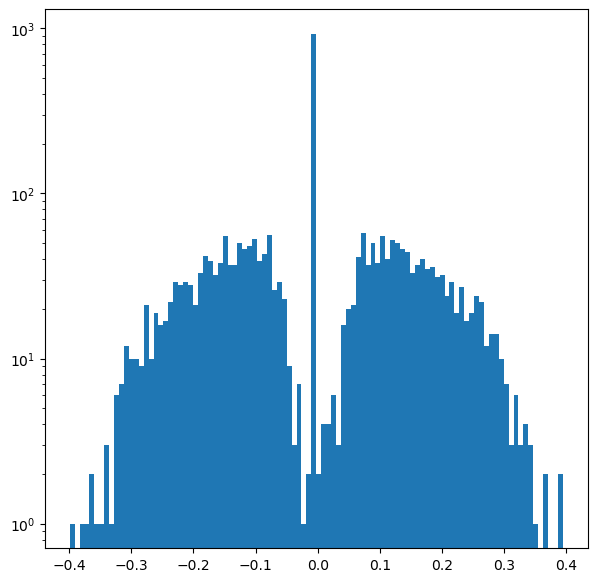

In [3]:
import matplotlib.pyplot as plt
w = qmodel.layers[2].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print(w)
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))